In [1]:
import shap
import joblib
import os
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# XGBoost model 

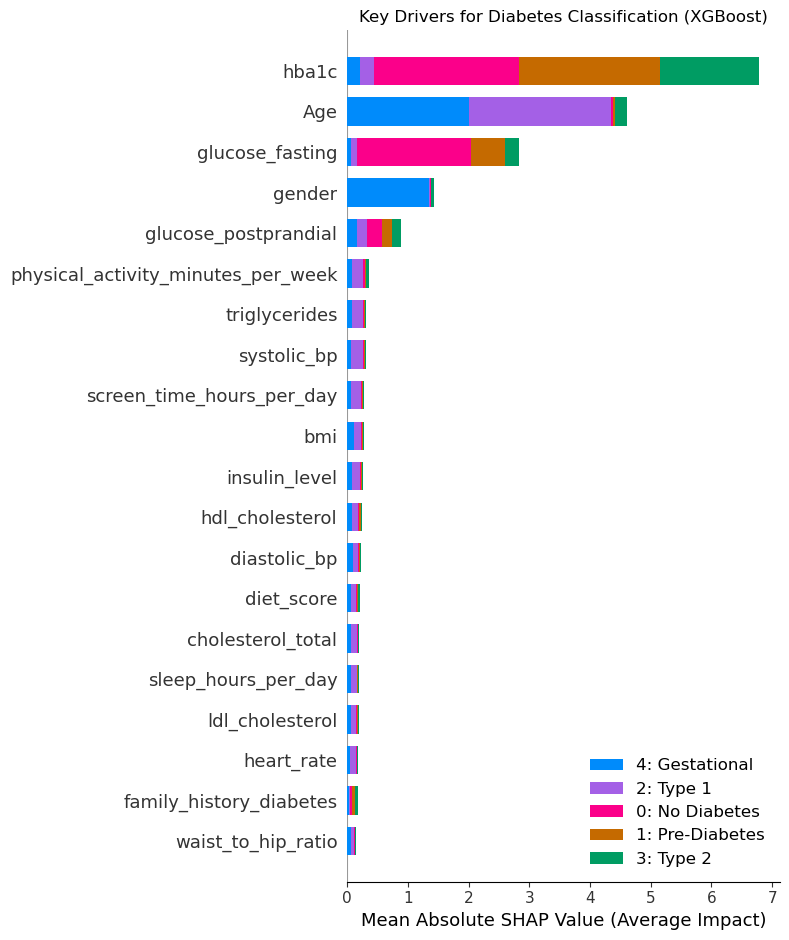

In [2]:
xgb_model = joblib.load('../artifacts/xgboost_model.pkl')

X_test_unscaled = pd.read_csv('../data/processed/X_test.csv')

feature_order = xgb_model.feature_names_in_
X_test_unscaled = X_test_unscaled[feature_order]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_unscaled)

target_names = [
    '0: No Diabetes', 
    '1: Pre-Diabetes', 
    '2: Type 1', 
    '3: Type 2', 
    '4: Gestational'
]

shap.summary_plot(
    shap_values, 
    X_test_unscaled,  
    class_names=target_names, 
    plot_type="bar", 
    show=False
)

plt.title("Key Drivers for Diabetes Classification (XGBoost)")
plt.xlabel("Mean Absolute SHAP Value (Average Impact)")
plt.tight_layout()
plt.show()

## XGBoost Model: Global Feature Importance Graph

The SHAP bar plot above displays feature importance for the XGBoost diabetes classification model.

### Key Findings

| Rank | Feature | Clinical Relevance |
|------|---------|-------------------|
| 1 | **HbA1c** | Dominant predictor—gold standard clinical marker for diabetes |
| 2 | **Age** | Well-established risk factor for metabolic dysfunction |
| 3 | **glucose_fasting** | Standard screening marker for diabetes |
| 4 | **gender** | Biological sex influences metabolic risk |
| 5 | **glucose_postprandial** | Post-meal glucose provides additional signal |

### Clinical Validation

The model learned the correct clinical hierarchy: HbA1c and glucose metrics dominate predictions, while lifestyle factors and secondary markers contribute appropriately.

# K-Means model

Sample size: 1000
Cluster distribution in sample:
  Cluster 0: 321 patients (32.1%)
  Cluster 1: 359 patients (35.9%)
  Cluster 2: 320 patients (32.0%)

Validation accuracy: 80.0%

SHAP values type: <class 'numpy.ndarray'>
Shape: (1000, 39, 3)


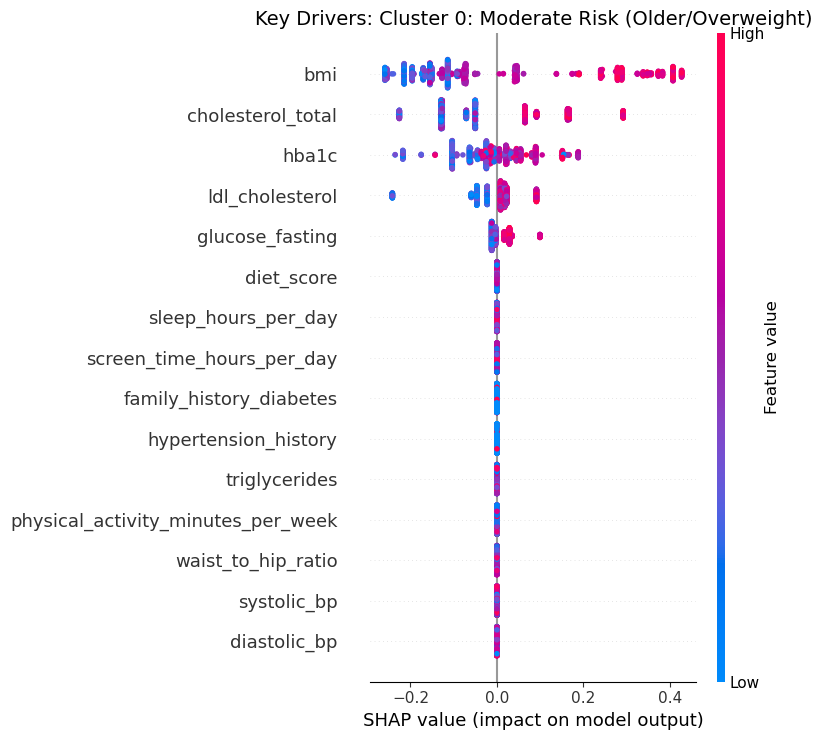

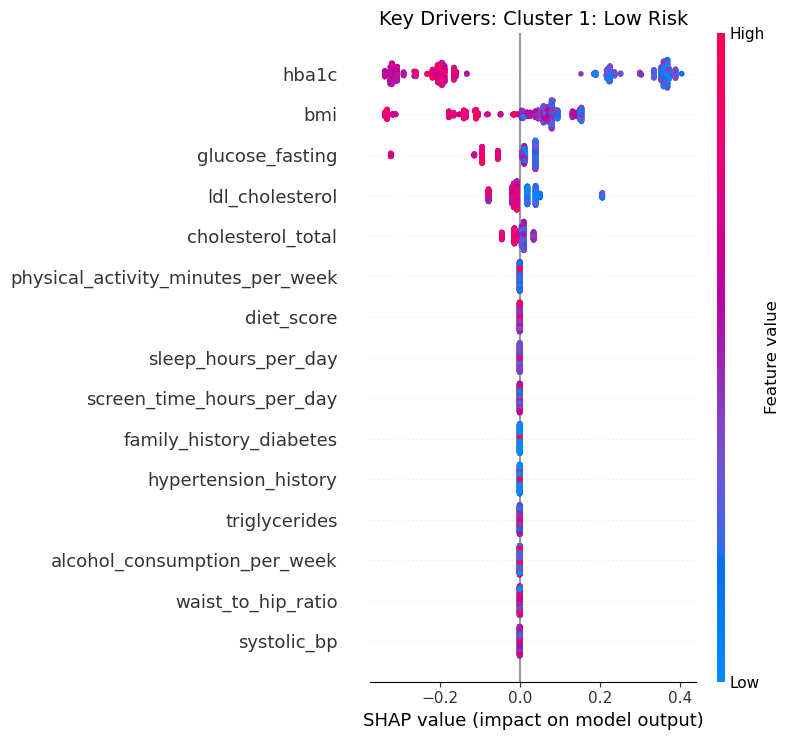

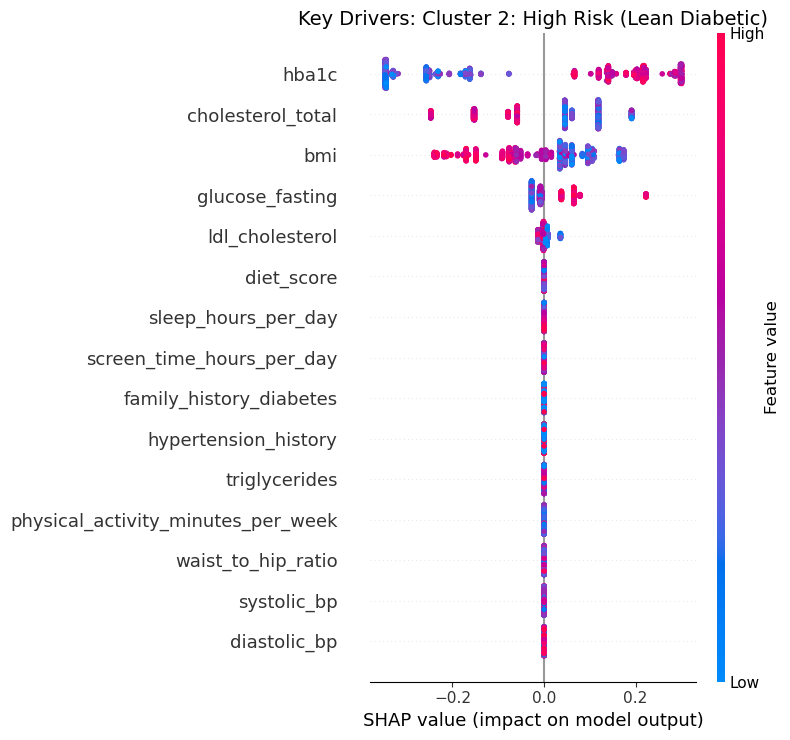


TOP FEATURES DRIVING EACH CLUSTER

Cluster 0: Moderate Risk (Older/Overweight):
  bmi: 0.2004
  cholesterol_total: 0.1192
  hba1c: 0.0581
  ldl_cholesterol: 0.0385
  glucose_fasting: 0.0154

Cluster 1: Low Risk:
  hba1c: 0.2801
  bmi: 0.1124
  glucose_fasting: 0.0499
  ldl_cholesterol: 0.0328
  cholesterol_total: 0.0126

Cluster 2: High Risk (Lean Diabetic):
  hba1c: 0.2330
  cholesterol_total: 0.1067
  bmi: 0.0899
  glucose_fasting: 0.0345
  ldl_cholesterol: 0.0057


In [4]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X_test_scaled = pd.read_csv('../data/processed/X_test_scaled.csv')
kmeans_full = joblib.load('../artifacts/kmeans_model.pkl')
all_features = X_test_scaled.columns.tolist()

X_sample = X_test_scaled.sample(n=1000, random_state=42)
cluster_sample = kmeans_full.predict(X_sample)

print(f"Sample size: {len(X_sample)}")
print(f"Cluster distribution in sample:")
for c in range(3):
    count = (cluster_sample == c).sum()
    print(f"  Cluster {c}: {count} patients ({count/len(cluster_sample)*100:.1f}%)")

X_train, X_val, y_train, y_val = train_test_split(
    X_sample, cluster_sample, test_size=0.2, random_state=42, stratify=cluster_sample
)

surrogate = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=50,
    min_samples_leaf=25,
    random_state=42
)
surrogate.fit(X_train, y_train)

print(f"\nValidation accuracy: {surrogate.score(X_val, y_val):.1%}")

explainer = shap.TreeExplainer(surrogate)
shap_values_raw = explainer.shap_values(X_sample)

print(f"\nSHAP values type: {type(shap_values_raw)}")
if isinstance(shap_values_raw, list):
    print(f"List length: {len(shap_values_raw)}")
    print(f"Shape of class 0: {shap_values_raw[0].shape}")
else:
    print(f"Shape: {shap_values_raw.shape}")

if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw
elif len(shap_values_raw.shape) == 3:
    shap_values = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]
else:
    shap_values = [shap_values_raw]

cluster_names = {
    1: "Cluster 1: Low Risk",
    0: "Cluster 0: Moderate Risk (Older/Overweight)",
    2: "Cluster 2: High Risk (Lean Diabetic)"
}

for cluster_idx in range(3):
    plt.figure(figsize=(12, 8))
    
    sv_cluster = shap_values[cluster_idx]
    n_samples = min(sv_cluster.shape[0], X_sample.shape[0])
    
    shap.summary_plot(
        sv_cluster[:n_samples],
        X_sample.iloc[:n_samples],
        feature_names=all_features,
        show=False,
        max_display=15
    )
    
    plt.title(f"Key Drivers: {cluster_names[cluster_idx]}", fontsize=14)
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 60)
print("TOP FEATURES DRIVING EACH CLUSTER")
print("=" * 60)

for cluster_idx in range(3):
    sv_cluster = shap_values[cluster_idx]
    mean_abs_shap = np.abs(sv_cluster).mean(axis=0)
    feature_importance = pd.DataFrame({
        'Feature': all_features,
        'Mean |SHAP|': mean_abs_shap
    }).sort_values('Mean |SHAP|', ascending=False)
    
    print(f"\n{cluster_names[cluster_idx]}:")
    for _, row in feature_importance.head(5).iterrows():
        print(f"  {row['Feature']}: {row['Mean |SHAP|']:.4f}")

# Patient Segment Profiles

## Cluster 0: Low-Risk / Healthy Reference Segment
- **Statistical Core**: 23,211 patients (~35% of sample)
- **Clinical Profile**: Youngest cohort (avg. age 44) with normal BMI (24.3), normal HbA1c (5.80%), and normal fasting glucose (100 mg/dL). Lowest family history of diabetes (11.7%).
- **Key Differentiator**: Absence of all major risk factors—lowest age, BMI, glucose, HbA1c, and genetic predisposition.
- **Practical Context**: Serves as the healthy control group. Prevention and maintenance strategies are most appropriate.

## Cluster 2: Moderate Risk / Age & Lifestyle-Driven Segment
- **Statistical Core**: 22,898 patients (~34% of sample)
- **Clinical Profile**: Oldest cohort (avg. age 57) with highest BMI (28.3 - overweight range), elevated HbA1c (6.73% - prediabetic range), and elevated fasting glucose (115 mg/dL). Moderate family history (22.9%).
- **Key Differentiator**: Risk primarily driven by age and elevated BMI rather than extreme glycemic dysfunction.
- **Practical Context**: Traditional "lifestyle risk" group. Weight management, physical activity, and dietary interventions are highest priority.

## Cluster 1: High-Risk / Genetic-Metabolic Segment (Lean Diabetic Profile)
- **Statistical Core**: 20,479 patients (~31% of sample)
- **Clinical Profile**: HbA1c in diabetic range (7.09%) and elevated fasting glucose (118 mg/dL) despite normal BMI (24.1). **Highest family history of diabetes (31.9%)** —nearly 3x higher than low-risk group.
- **Key Differentiator**: Severe glycemic dysfunction independent of obesity, strongly associated with genetic predisposition.
- **Practical Context**: Highest clinical priority. These patients may be missed by BMI-based screening but require urgent medical intervention. The strong family history component suggests genetic susceptibility.

---

## Summary Table

| Cluster | Label | Age | BMI | HbA1c | Fasting Glucose | Family History | Patients |
|---------|-------|-----|-----|-------|-----------------|----------------|----------|
| 0 | Low Risk | 44 | 24.3 | 5.80% | 100 mg/dL | 11.7% | 23,211 |
| 2 | Moderate Risk | 57 | 28.3 | 6.73% | 115 mg/dL | 22.9% | 22,898 |
| 1 | High Risk | 49 | 24.1 | **7.09%** | **118 mg/dL** | **31.9%** | 20,479 |

